## Diff Expression for ATAC-seq (using enhancers)

In [27]:
library(data.table)
library(stringr)
# plotting
library(ggplot2)
library(cowplot)
# DE analysis
#library(limma)
library(edgeR)
library(DESeq2)
library(UpSetR)
library(gridExtra)
library(clusterProfiler)
library(org.Hs.eg.db)

In [47]:
results_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP/results/DESeq2/"

## 0. Read in Counts

In [23]:
# Read in counts for merged (used for general )
upm <- fread("../data/counts/UPM_NEC_ATAC_CUWA1kb_MUMERGE.txt")
upm_m <- fread("../data/counts/UPM_NEC_ATAC_CUWA1kb_merged.txt")
upm_summ <- fread("../data/counts/UPM_NEC_ATAC_CUWA1kb_merged.txt.summary")
count_cols <- c("Geneid", "Chr", "Start", "End", "Strand", "Length")
colnames_ <- c("UPM120_1", "UPM120_2", "UPM30_1", "UPM30_2", "Veh_1", "Veh_2")
colnames(upm) <- c(count_cols, colnames_); colnames(upm_summ) <- c("Status", colnames_); colnames(upm_m) <- c(count_cols, colnames_)

upm_summ

# get the matrices
upm_nec_matrix <- as.matrix(upm[,7:ncol(upm)])
rownames(upm_nec_matrix) <- upm$Geneid
upm <- upm_nec_matrix

upm_nec_matrix <- as.matrix(upm_m[,7:ncol(upm_m)])
rownames(upm_nec_matrix) <- upm_m$Geneid
upm_m <- upm_nec_matrix
upm[1:2,]
upm_m[1:2,]

Status,UPM120_1,UPM120_2,UPM30_1,UPM30_2,Veh_1,Veh_2
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
Assigned,19495286,10609004,17870121,17280123,18951792,14475153
Unassigned_Unmapped,8783638,5304385,9346340,11021732,11071559,10096762
Unassigned_MappingQuality,0,0,0,0,0,0
Unassigned_Chimera,0,0,0,0,0,0
Unassigned_FragmentLength,0,0,0,0,0,0
Unassigned_Duplicate,0,0,0,0,0,0
Unassigned_MultiMapping,24351013,14576168,23115684,27633604,32279158,28602551
Unassigned_Secondary,0,0,0,0,0,0
Unassigned_Nonjunction,0,0,0,0,0,0


,UPM120_1,UPM120_2,UPM30_1,UPM30_2,Veh_1,Veh_2
chr1:629266,411,353,674,591,786,704
chr1:629925,4573,4025,6146,5718,7228,6544


,UPM120_1,UPM120_2,UPM30_1,UPM30_2,Veh_1,Veh_2
"chr1:629266,chr1:629925",4589,4037,6181,5744,7284,6579
chr1:631361,83,84,160,130,203,185


In [29]:
# Read in counts for merged (used for general )
wsp_nec <- fread("../data/counts/WSP_NEC_ATAC_CUWA1kb_MUMERGE.txt")
wsp_nec_m <- fread("../data/counts/WSP_NEC_ATAC_CUWA1kb_merged.txt")
wsp_nec_summ <- fread("../data/counts/WSP_NEC_ATAC_CUWA1kb_merged.txt.summary")
colnames_ <- c("D0_WSP120_1", "D0_WSP120_2", "D0_WSP30_1", "D0_WSP30_2", "D0_Veh_1", "D0_Veh_2",
"D21_WSP120_1", "D21_WSP120_2", "D21_WSP30_1", "D21_WSP30_2", "D21_Veh_1", "D21_Veh_2")
colnames(wsp_nec) <- c(count_cols, colnames_); colnames(wsp_nec_summ) <- c("Status", colnames_); colnames(wsp_nec_m) <- c(count_cols, colnames_)

wsp_nec_summ

# get the matrices
wsp_nec_matrix <- as.matrix(wsp_nec[,7:ncol(wsp_nec)])
rownames(wsp_nec_matrix) <- wsp_nec$Geneid
wsp_nec <- wsp_nec_matrix

wsp_nec_matrix <- as.matrix(wsp_nec_m[,7:ncol(wsp_nec_m)])
rownames(wsp_nec_matrix) <- wsp_nec_m$Geneid
wsp_nec_m <- wsp_nec_matrix
wsp_nec[1:2,]
wsp_nec_m[1:2,]

Status,D0_WSP120_1,D0_WSP120_2,D0_WSP30_1,D0_WSP30_2,D0_Veh_1,D0_Veh_2,D21_WSP120_1,D21_WSP120_2,D21_WSP30_1,D21_WSP30_2,D21_Veh_1,D21_Veh_2
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Assigned,14114374,12079201,15758236,13093892,16042858,10964540,15462503,11137430,14052060,15934520,13942063,12575397
Unassigned_Unmapped,10170958,7908348,13842263,8533111,9116280,7704553,8793632,6028262,9005719,8264885,9404292,9814832
Unassigned_MappingQuality,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_Chimera,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_FragmentLength,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_Duplicate,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_MultiMapping,28963697,22590990,33128478,24458895,25661577,20603649,25110182,16440970,20357059,21804526,23090773,25157235
Unassigned_Secondary,0,0,0,0,0,0,0,0,0,0,0,0
Unassigned_Nonjunction,0,0,0,0,0,0,0,0,0,0,0,0


,D0_WSP120_1,D0_WSP120_2,D0_WSP30_1,D0_WSP30_2,D0_Veh_1,D0_Veh_2,D21_WSP120_1,D21_WSP120_2,D21_WSP30_1,D21_WSP30_2,D21_Veh_1,D21_Veh_2
chr1:629266,323,273,389,260,479,368,502,422,462,320,413,326
chr1:629925,3539,3261,4176,3493,4653,3847,5581,4457,4825,4284,4530,3902


,D0_WSP120_1,D0_WSP120_2,D0_WSP30_1,D0_WSP30_2,D0_Veh_1,D0_Veh_2,D21_WSP120_1,D21_WSP120_2,D21_WSP30_1,D21_WSP30_2,D21_Veh_1,D21_Veh_2
"chr1:629266,chr1:629925",3570,3278,4208,3508,4680,3867,5614,4471,4845,4308,4552,3925
chr1:631361,96,72,116,57,113,50,164,93,134,77,109,80


In [21]:
# Read in counts for merged (used for general )
wsp_b2b <- fread("../data/counts/WSP_B2B_ATAC_CUWA1kb_MUMERGE.txt")
wsp_b2b_m <- fread("../data/counts/WSP_B2B_ATAC_CUWA1kb_merged.txt")
wsp_b2b_summ <- fread("../data/counts/WSP_B2B_ATAC_CUWA1kb_merged.txt.summary")
colnames_ <- c("WSP120_1", "WSP120_2", "WSP30_1", "WSP30_2", "Veh_1", "Veh_2")
colnames(wsp_b2b) <- c(count_cols, colnames_); colnames(wsp_b2b_summ) <- c("Status", colnames_); colnames(wsp_b2b_m) <- c(count_cols, colnames_)

wsp_b2b_summ

# get the matrices
wsp_b2b_matrix <- as.matrix(wsp_b2b[,7:ncol(wsp_b2b)])
rownames(wsp_b2b_matrix) <- wsp_b2b$Geneid
wsp_b2b <- wsp_b2b_matrix

wsp_b2b_matrix <- as.matrix(wsp_b2b_m[,7:ncol(wsp_b2b_m)])
rownames(wsp_b2b_matrix) <- wsp_b2b_m$Geneid
wsp_b2b_m <- wsp_b2b_matrix
wsp_b2b[1:2,]
wsp_b2b_m[1:2,]

Status,WSP120_1,WSP120_2,WSP30_1,WSP30_2,Veh_1,Veh_2
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
Assigned,16635991,31828036,19959600,17244139,23346584,17813152
Unassigned_Unmapped,10772012,21184139,13188605,11165732,13804916,14550358
Unassigned_MappingQuality,0,0,0,0,0,0
Unassigned_Chimera,0,0,0,0,0,0
Unassigned_FragmentLength,0,0,0,0,0,0
Unassigned_Duplicate,0,0,0,0,0,0
Unassigned_MultiMapping,20454611,22239103,20428775,16983578,20038673,14993304
Unassigned_Secondary,0,0,0,0,0,0
Unassigned_Nonjunction,0,0,0,0,0,0


,WSP120_1,WSP120_2,WSP30_1,WSP30_2,Veh_1,Veh_2
chr1:629266,317,456,271,207,356,205
chr1:629925,2672,3685,2586,1750,2642,2178


,WSP120_1,WSP120_2,WSP30_1,WSP30_2,Veh_1,Veh_2
"chr1:629266,chr1:629925",2681,3692,2595,1756,2653,2184
chr1:631361,45,42,45,24,37,41


## 1. Design & PCA

In [24]:
design_upm <- data.table("Name"=c("UPM120_1", "UPM120_2", "UPM30_1", "UPM30_2", "Veh_1", "Veh_2"), 
                    "Replicate"=c("1", "2", "1", "2", "1", "2"), 
                    "Treatment"=c("UPM120", "UPM120", "UPM30", "UPM30", "Veh", "Veh"))
design_upm$Replicate <- as.factor(design_upm$Replicate)
design_upm$Treatment <- as.factor(design_upm$Treatment)
design_upm

design_wsp_nec <- data.table("Name"=c("D0_WSP120_1", "D0_WSP120_2", "D0_WSP30_1", "D0_WSP30_2", "D0_Veh_1", "D0_Veh_2",
"D21_WSP120_1", "D21_WSP120_2", "D21_WSP30_1", "D21_WSP30_2", "D21_Veh_1", "D21_Veh_2"), 
                    "Replicate"=c("1", "2", "1", "2", "1", "2", "3", "4", "3", "4", "3", "4"), 
					"CellType"=c("D0", "D0", "D0", "D0", "D0", "D0", "D21", "D21", "D21", "D21", "D21", "D21"), 
                    "Treatment"=c("WSP120", "WSP120", "WSP30", "WSP30", "Veh", "Veh",
					"WSP120", "WSP120", "WSP30", "WSP30", "Veh", "Veh"))
design_wsp_nec$Replicate <- as.factor(design_wsp_nec$Replicate)
design_wsp_nec$CellType <- as.factor(design_wsp_nec$CellType)
design_wsp_nec$Treatment <- as.factor(design_wsp_nec$Treatment)
design_wsp_nec

design_wsp_b2b <- data.table("Name"=c("WSP120_1", "WSP120_2", "WSP30_1", "WSP30_2", "Veh_1", "Veh_2"), 
                    "Replicate"=c("1", "2", "1", "2", "1", "2"), 
                    "Treatment"=c("WSP120", "WSP120", "WSP30", "WSP30", "Veh", "Veh"))
design_wsp_b2b$Replicate <- as.factor(design_wsp_b2b$Replicate)
design_wsp_b2b$Treatment <- as.factor(design_wsp_b2b$Treatment)
design_wsp_b2b


Name,Replicate,Treatment
<chr>,<fct>,<fct>
UPM120_1,1,UPM120
UPM120_2,2,UPM120
UPM30_1,1,UPM30
UPM30_2,2,UPM30
Veh_1,1,Veh
Veh_2,2,Veh


Name,Replicate,CellType,Treatment
<chr>,<fct>,<fct>,<fct>
D0_WSP120_1,1,D0,WSP120
D0_WSP120_2,2,D0,WSP120
D0_WSP30_1,1,D0,WSP30
D0_WSP30_2,2,D0,WSP30
D0_Veh_1,1,D0,Veh
D0_Veh_2,2,D0,Veh
D21_WSP120_1,3,D21,WSP120
D21_WSP120_2,4,D21,WSP120
D21_WSP30_1,3,D21,WSP30


Name,Replicate,Treatment
<chr>,<fct>,<fct>
WSP120_1,1,WSP120
WSP120_2,2,WSP120
WSP30_1,1,WSP30
WSP30_2,2,WSP30
Veh_1,1,Veh
Veh_2,2,Veh


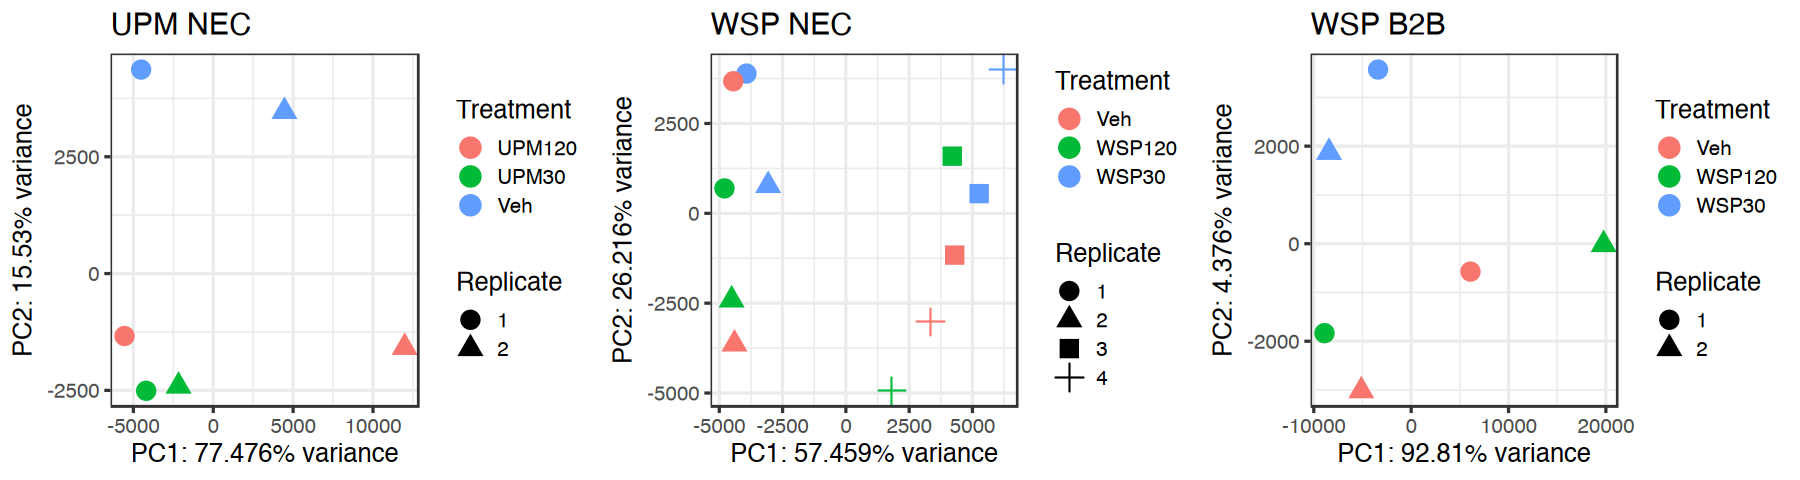

In [ ]:
## Some functions for initial comparison to assess batch effects
plotPCA_hope_meta <- function(counts, metadata, ntop=500, Treat=TRUE) {
    rv <- rowVars(counts)
    length(rv) == nrow(counts)
    select <- order(rv, decreasing = TRUE)[seq_len(min(ntop,  length(rv)))]
    pca <- prcomp(t(counts[select, ]))
      percentVar <- pca$sdev^2/sum(pca$sdev^2)
    if (Treat == TRUE) {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Treatment, shape=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    } else {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    }
  
}

p1 <- plotPCA_hope_meta(upm, metadata=design_upm, ntop=500) + ggtitle(paste0("UPM NEC"))
p2 <- plotPCA_hope_meta(wsp_nec, metadata=design_wsp_nec, ntop=500) + ggtitle(paste0("WSP NEC"))
p3 <- plotPCA_hope_meta(wsp_b2b, metadata=design_wsp_b2b, ntop=500) + ggtitle(paste0("WSP B2B"))
options(repr.plot.height = 4, repr.plot.width = 15)
plot_grid(p1, p2, p3, nrow=1)


## 2. Run DESeq2

In [31]:
# get the DESeq objects
# Original
dds_upm <- DESeqDataSetFromMatrix(countData = upm, colData = design_upm, design = ~ Treatment)
dds_wsp_nec <- DESeqDataSetFromMatrix(countData = wsp_nec, colData = design_wsp_nec, design = ~ Treatment + CellType)
dds_wsp_b2b <- DESeqDataSetFromMatrix(countData = wsp_b2b, colData = design_wsp_b2b, design = ~ Treatment)

# Merged
dds_upm_m <- DESeqDataSetFromMatrix(countData = upm_m, colData = design_upm, design = ~ Treatment)
dds_wsp_nec_m <- DESeqDataSetFromMatrix(countData = wsp_nec_m, colData = design_wsp_nec, design = ~ Treatment + CellType)
dds_wsp_b2b_m <- DESeqDataSetFromMatrix(countData = wsp_b2b_m, colData = design_wsp_b2b, design = ~ Treatment)


In [32]:
# make clear that reference is Vehicle
dds_upm$Treatment <- relevel(dds_upm$Treatment, ref = "Veh")
dds_wsp_nec$Treatment <- relevel(dds_wsp_nec$Treatment, ref = "Veh")
dds_wsp_b2b$Treatment <- relevel(dds_wsp_b2b$Treatment, ref = "Veh")
dds_upm_m$Treatment <- relevel(dds_upm_m$Treatment, ref = "Veh")
dds_wsp_nec_m$Treatment <- relevel(dds_wsp_nec_m$Treatment, ref = "Veh")
dds_wsp_b2b_m$Treatment <- relevel(dds_wsp_b2b_m$Treatment, ref = "Veh")

### 2A. Size Factors
I want to see what I get when using size factors based on Merge vs full mapped reads

In [33]:
# estimate size factors based on merged ( and not to compare)
dds_upm <- estimateSizeFactors(dds_upm)
dds_upm_m <- estimateSizeFactors(dds_upm_m)
dds_wsp_nec <- estimateSizeFactors(dds_wsp_nec)
dds_wsp_nec_m <- estimateSizeFactors(dds_wsp_nec_m)
dds_wsp_b2b <- estimateSizeFactors(dds_wsp_b2b)
dds_wsp_b2b_m <- estimateSizeFactors(dds_wsp_b2b_m)

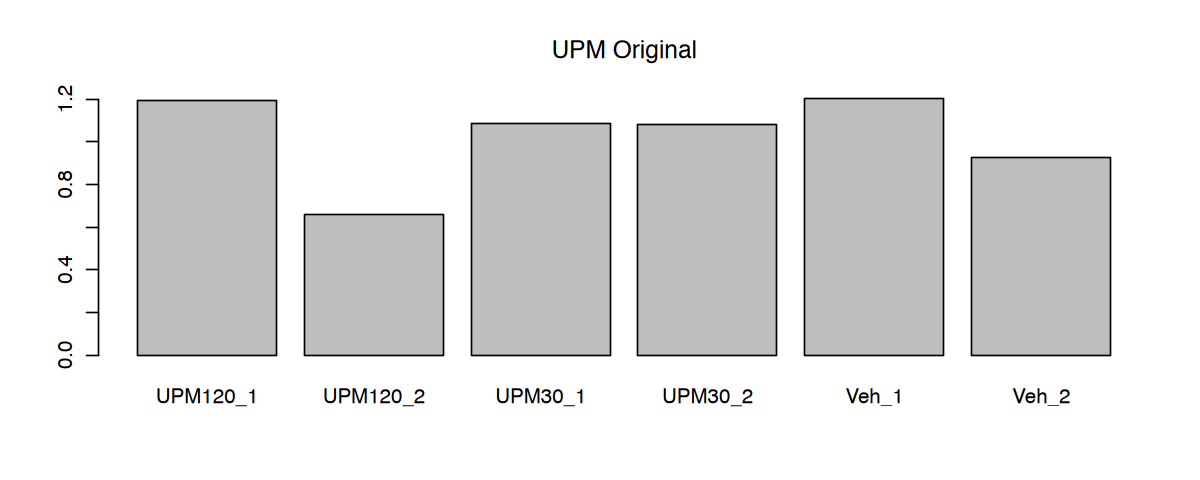

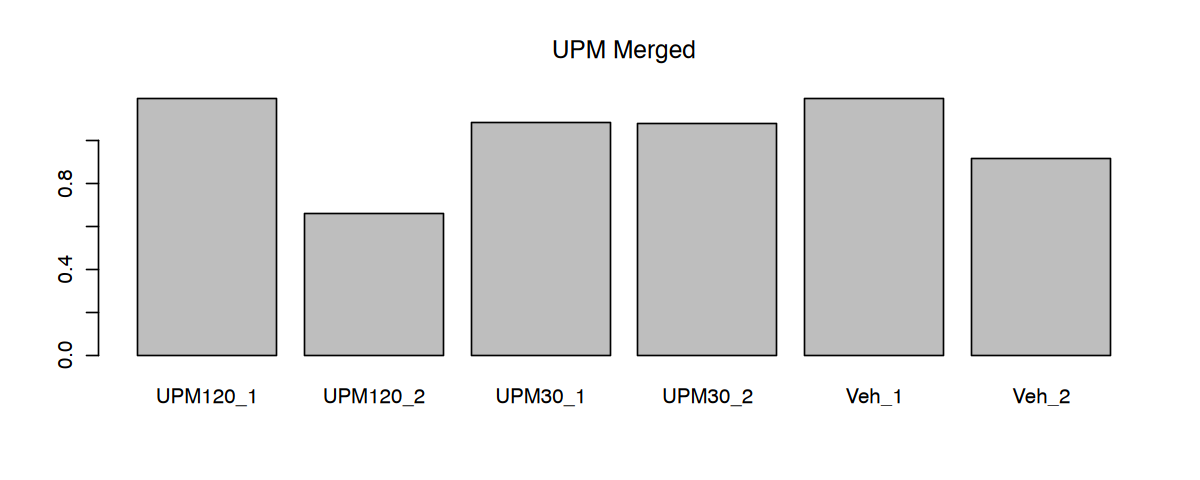

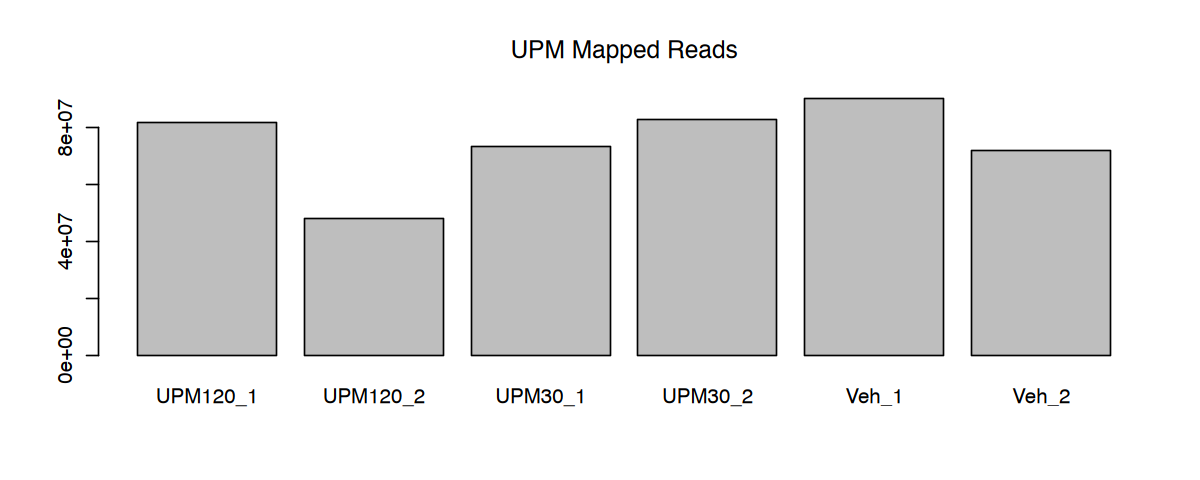

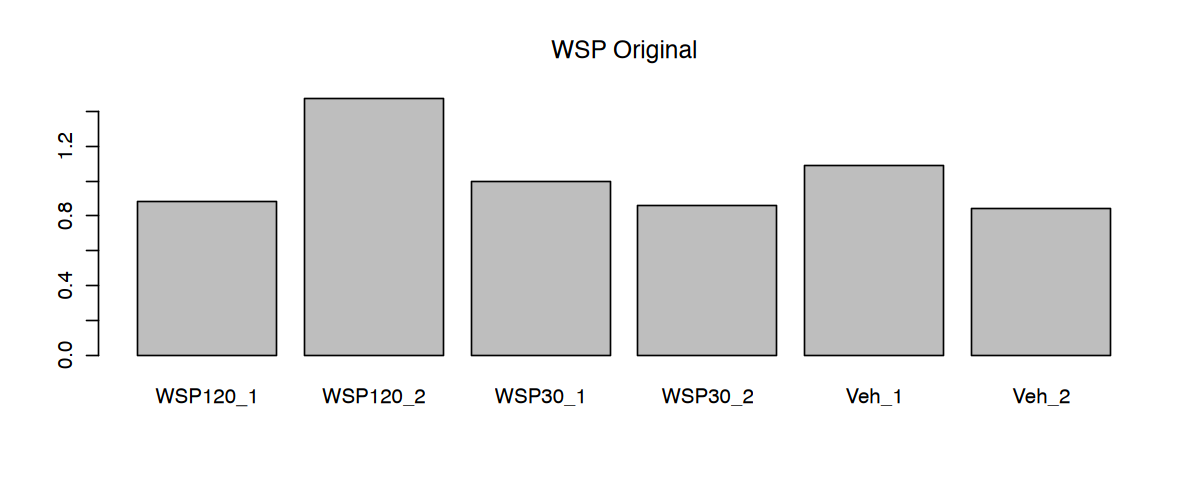

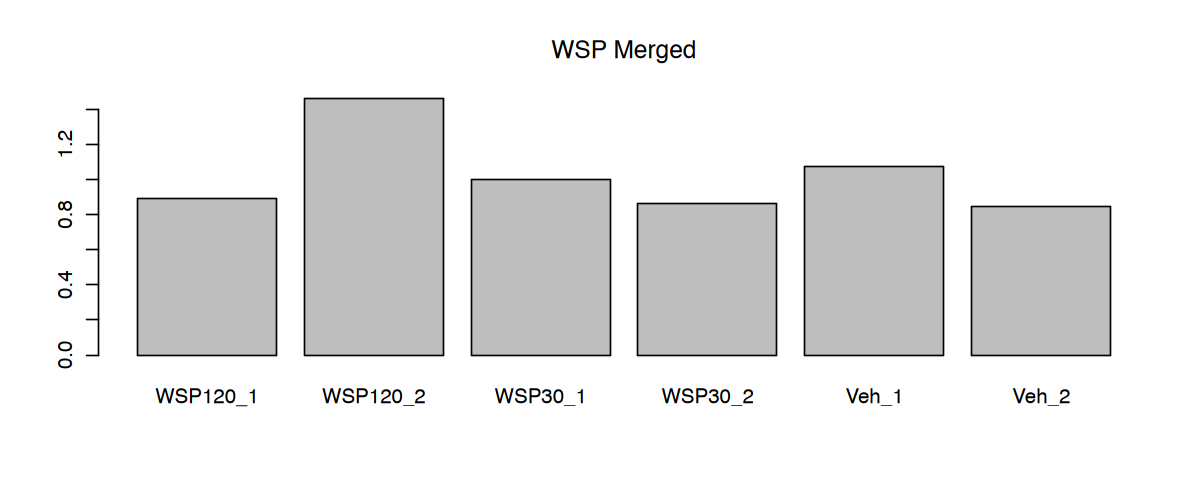

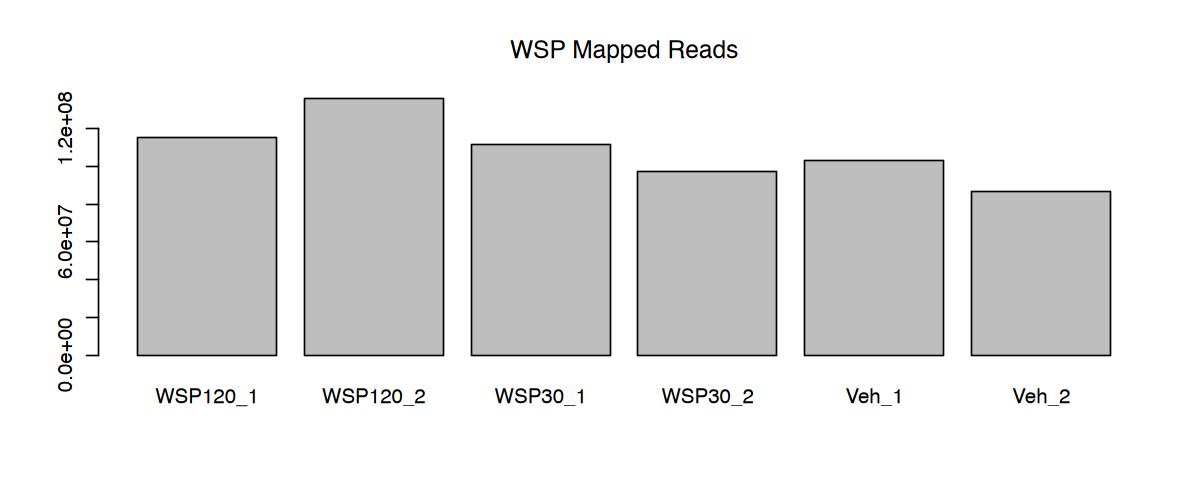

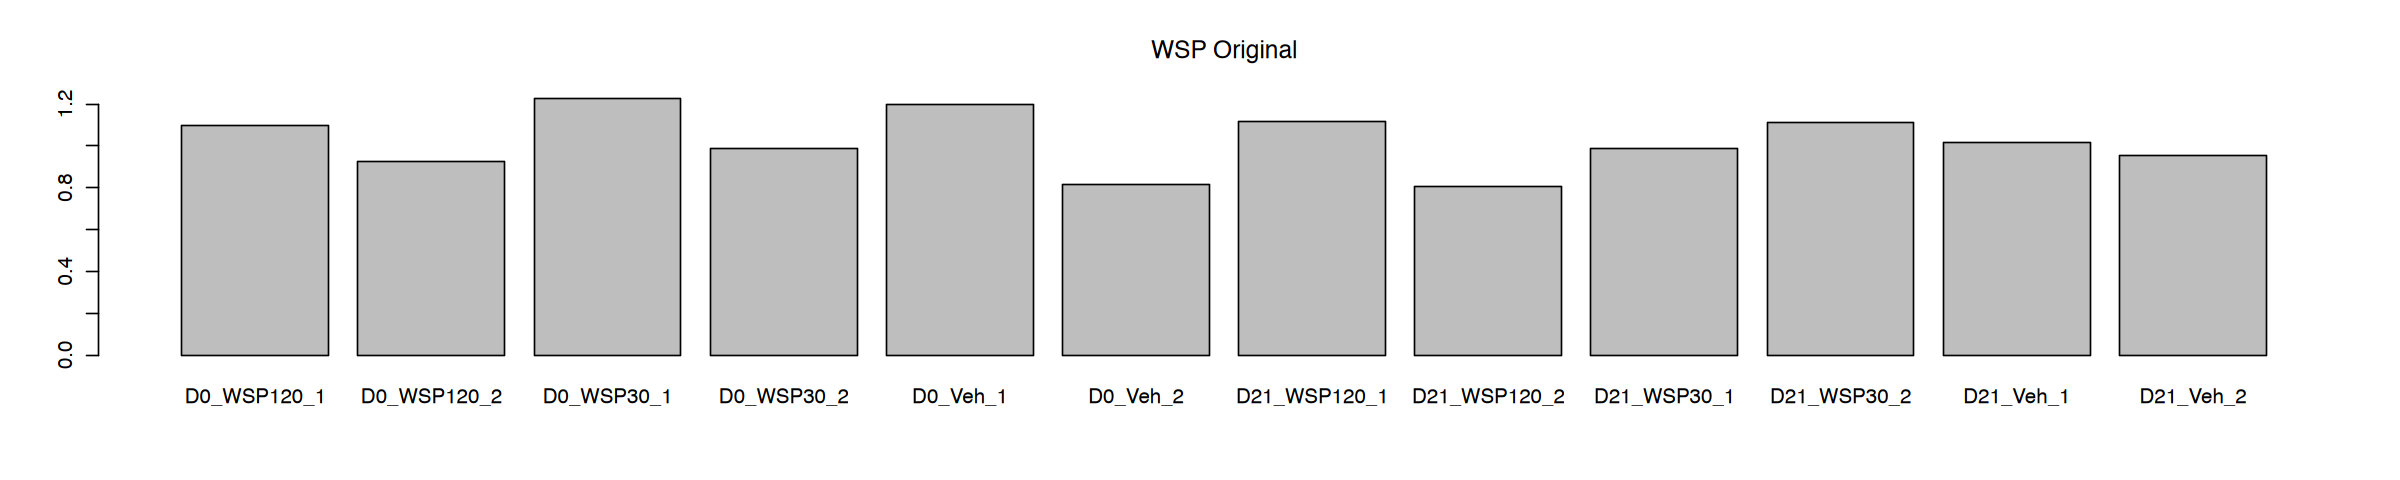

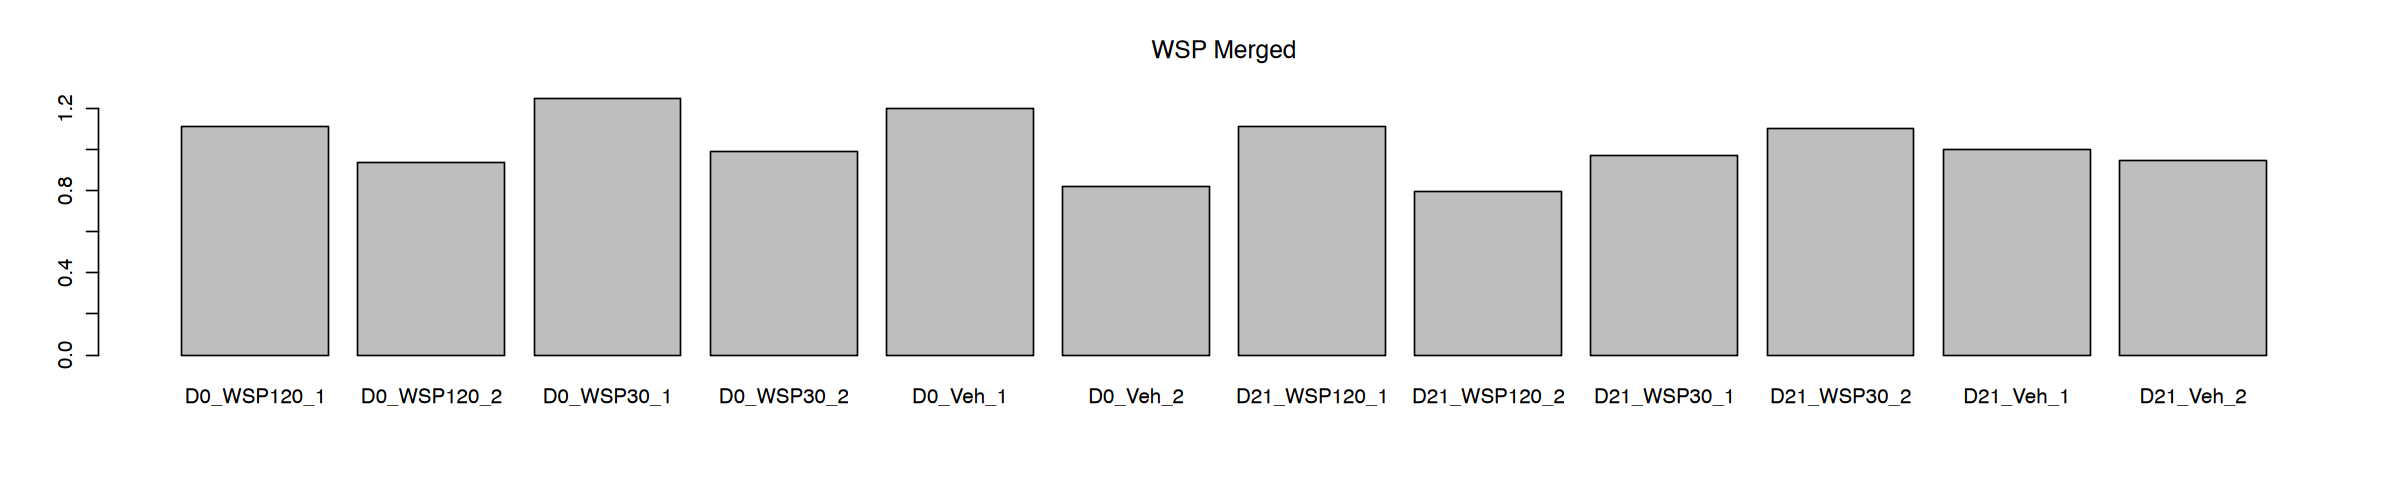

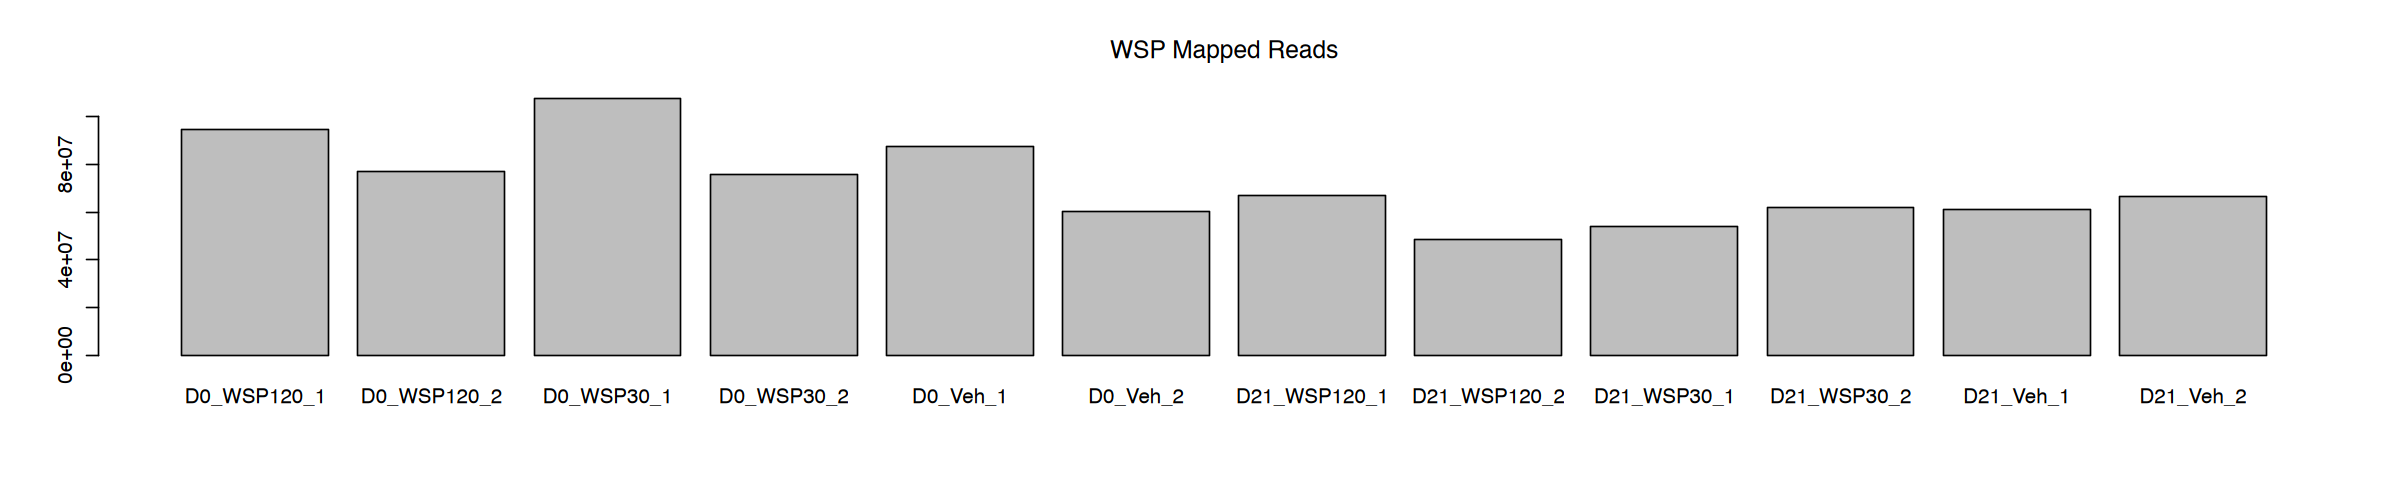

In [35]:
status_keep = c("Assigned", "Unassigned_NoFeatures")

# plot
options(repr.plot.height=4, repr.plot.width=10)
barplot(sizeFactors(dds_upm), main="UPM Original")
barplot(sizeFactors(dds_upm_m), main="UPM Merged")
barplot(colSums(upm_summ[upm_summ$Status %in% status_keep, -c("Status")]), main="UPM Mapped Reads")

barplot(sizeFactors(dds_wsp_b2b), main="WSP Original")
barplot(sizeFactors(dds_wsp_b2b_m), main="WSP Merged")
barplot(colSums(wsp_b2b_summ[wsp_b2b_summ$Status %in% status_keep, -c("Status")]), main="WSP Mapped Reads")

options(repr.plot.height=4, repr.plot.width=20)
barplot(sizeFactors(dds_wsp_nec), main="WSP Original")
barplot(sizeFactors(dds_wsp_nec_m), main="WSP Merged")
barplot(colSums(wsp_nec_summ[wsp_nec_summ$Status %in% status_keep, -c("Status")]), main="WSP Mapped Reads")




#### General relationships look similar so we'll just used the merged ones to make things simple

In [37]:
sizeFactors(dds_upm) <- sizeFactors(dds_upm_m)
sizeFactors(dds_wsp_nec) <- sizeFactors(dds_wsp_nec_m)
sizeFactors(dds_wsp_b2b) <- sizeFactors(dds_wsp_b2b_m)

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

using ntop=500 top features by variance

using ntop=500 top features by variance

using ntop=500 top features by variance



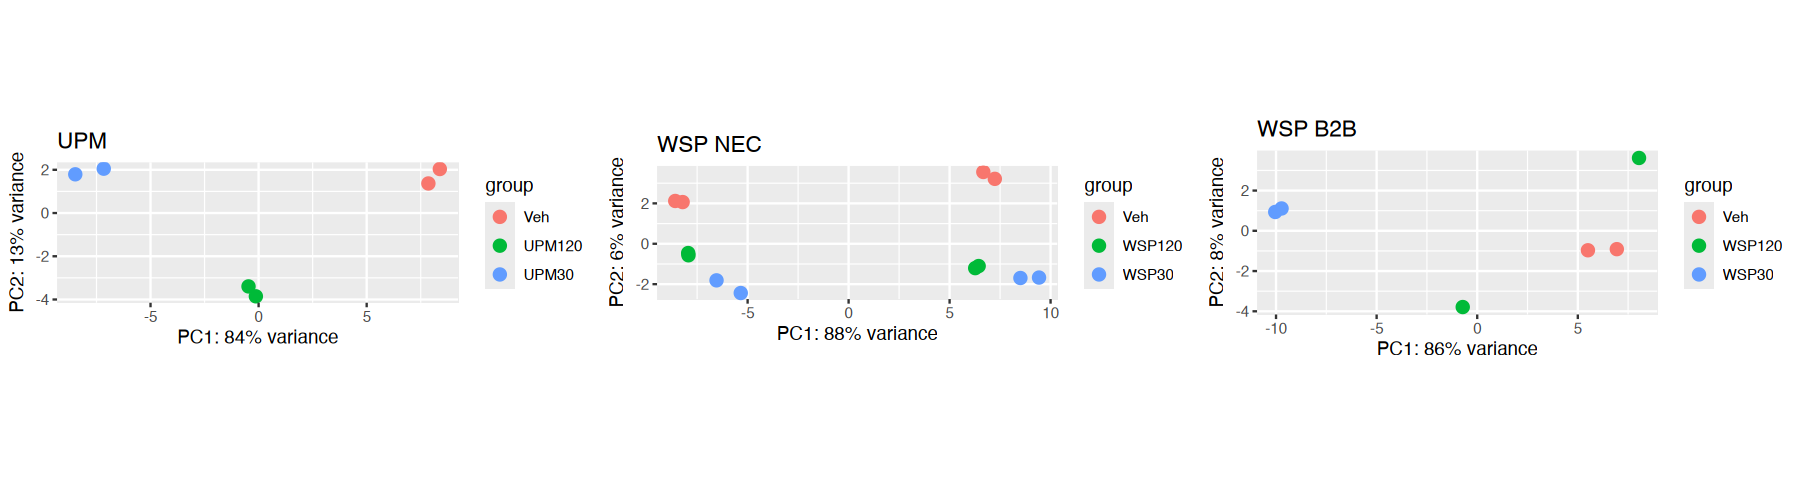

In [40]:
# plot PCA with with DESeq2 size factors
options(repr.plot.width=15, repr.plot.height=4)
# Ratio
vsd1 <- vst(dds_upm, blind = FALSE)
vsd3 <- vst(dds_wsp_nec, blind = FALSE)
vsd4 <- vst(dds_wsp_b2b, blind = FALSE)
p1 <- plotPCA(vsd1, intgroup = "Treatment") + ggtitle(paste0("UPM"))
p3 <- plotPCA(vsd3, intgroup = "Treatment") + ggtitle(paste0("WSP NEC"))
p4 <- plotPCA(vsd4, intgroup = "Treatment") + ggtitle(paste0("WSP B2B"))
plot_grid(p1, p3, p4, nrow=1)



### 2B. Estimate Dispersions and Run Significance Tests

In [41]:
dds_upm = estimateDispersions(dds_upm) 
dds_wsp_nec = estimateDispersions(dds_wsp_nec)
dds_wsp_b2b = estimateDispersions(dds_wsp_b2b) 


gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



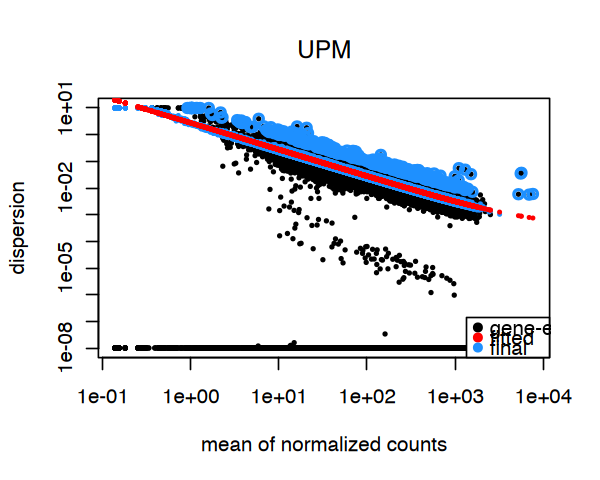

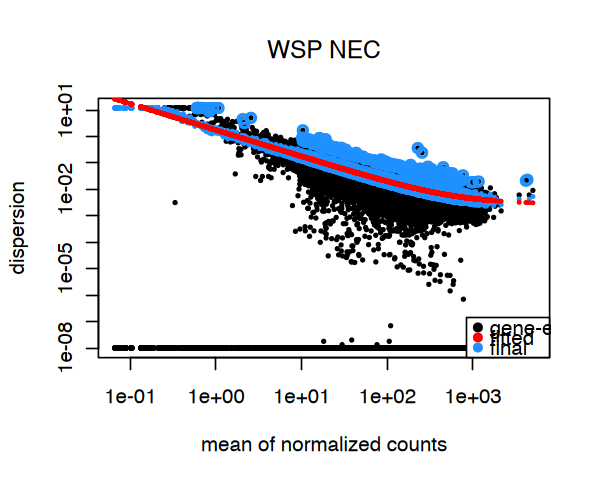

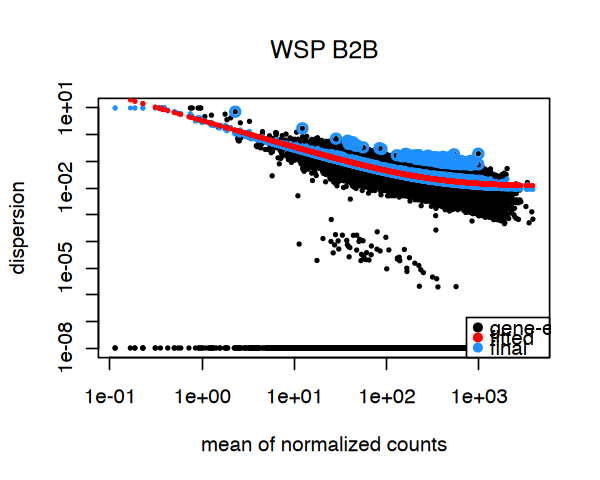

In [42]:
options(repr.plot.height=4, repr.plot.width=5)
plotDispEsts(dds_upm, main= "UPM")
plotDispEsts(dds_wsp_nec, main= "WSP NEC")
plotDispEsts(dds_wsp_b2b, main= "WSP B2B")

In [43]:
dds_upm = nbinomWaldTest(dds_upm)
dds_wsp_nec = nbinomWaldTest(dds_wsp_nec)
dds_wsp_b2b = nbinomWaldTest(dds_wsp_b2b)

### 2C. Get Results

In [59]:
binwidth_use=0.05
# Set your thresholds
padj_threshold <- 0.05
log2fc_threshold <- 0

In [60]:
# Get the significance comparisons ready
Up_Sig_UPM = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
Down_Sig_UPM = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
All_Sig_UPM = list("P120_vs_Veh_up"=c(), "P30_vs_Veh_up"=c(), "P120_vs_P30_up"=c(), 
                     "P120_vs_Veh_down"=c(), "P30_vs_Veh_down"=c(), "P120_vs_P30_down"=c())

Up_Sig_WSP_NEC = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
Down_Sig_WSP_NEC = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
All_Sig_WSP_NEC = list("P120_vs_Veh_up"=c(), "P30_vs_Veh_up"=c(), "P120_vs_P30_up"=c(), 
                     "P120_vs_Veh_down"=c(), "P30_vs_Veh_down"=c(), "P120_vs_P30_down"=c())

Up_Sig_WSP_B2B = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
Down_Sig_WSP_B2B = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
All_Sig_WSP_B2B = list("P120_vs_Veh_up"=c(), "P30_vs_Veh_up"=c(), "P120_vs_P30_up"=c(), 
                     "P120_vs_Veh_down"=c(), "P30_vs_Veh_down"=c(), "P120_vs_P30_down"=c())

[1] "UPM30 vs Veh"

out of 83439 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 2509, 3%
LFC < 0 (down)     : 564, 0.68%
outliers [1]       : 0, 0%
low counts [2]     : 16161, 19%
(mean count < 35)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
"Removed 1582 rows containing non-finite outside the scale range (`stat_bin()`)."


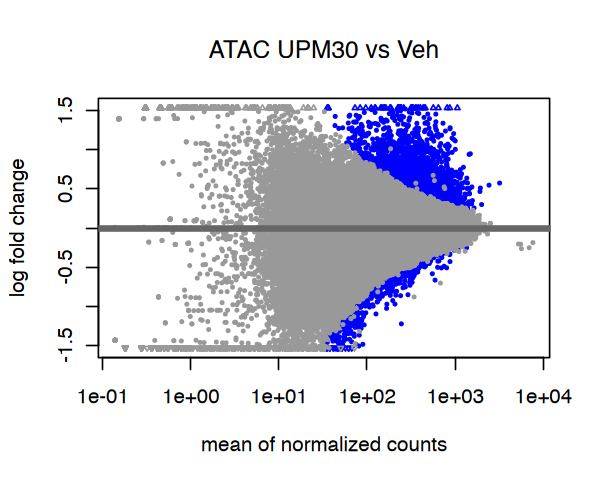

[1] 2509

[1] 564

Warning message:
"Removed 1582 rows containing missing values or values outside the scale range
(`geom_point()`)."


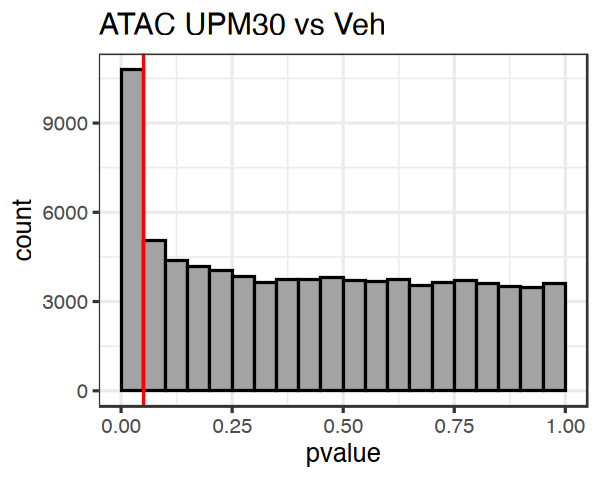

[1] "UPM120 vs Veh"

out of 83439 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1999, 2.4%
LFC < 0 (down)     : 480, 0.58%
outliers [1]       : 0, 0%
low counts [2]     : 19393, 23%
(mean count < 43)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



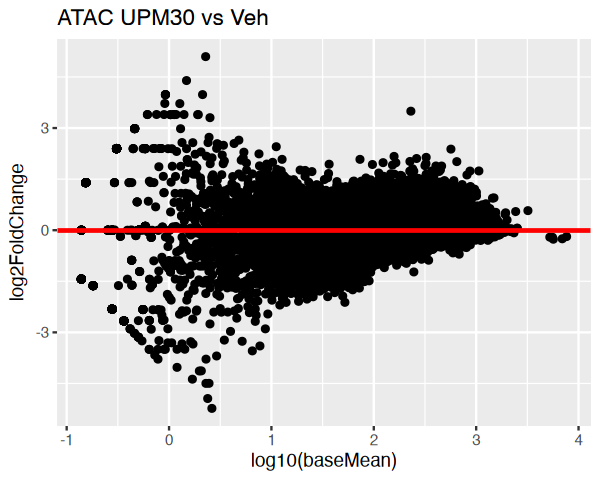

Warning message:
"Removed 1582 rows containing non-finite outside the scale range (`stat_bin()`)."


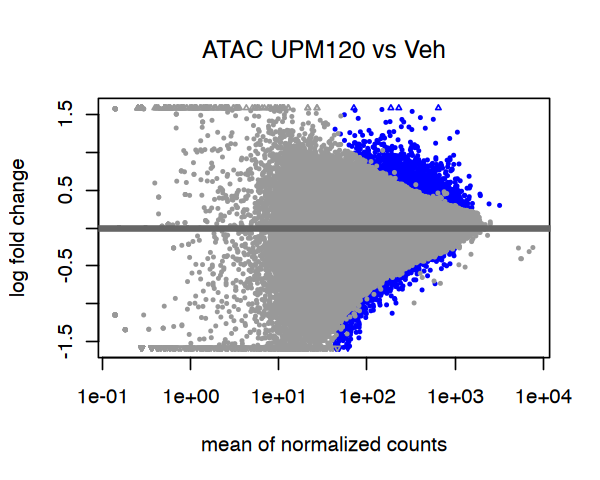

[1] 1999

[1] 480

Warning message:
"Removed 1582 rows containing missing values or values outside the scale range
(`geom_point()`)."


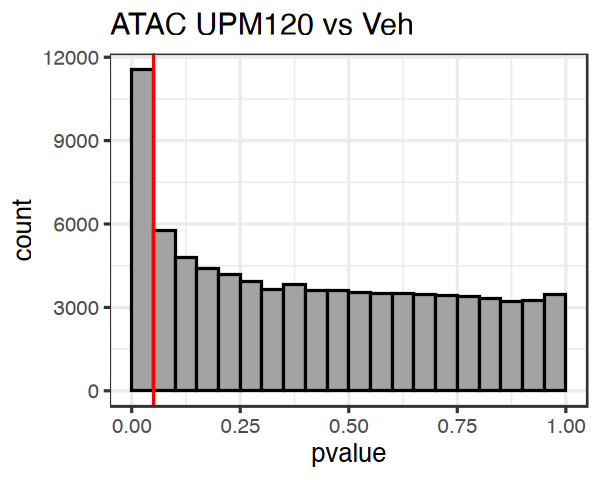

[1] "UPM120 vs UPM30"

out of 83439 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 498, 0.6%
LFC < 0 (down)     : 614, 0.74%
outliers [1]       : 0, 0%
low counts [2]     : 27474, 33%
(mean count < 70)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



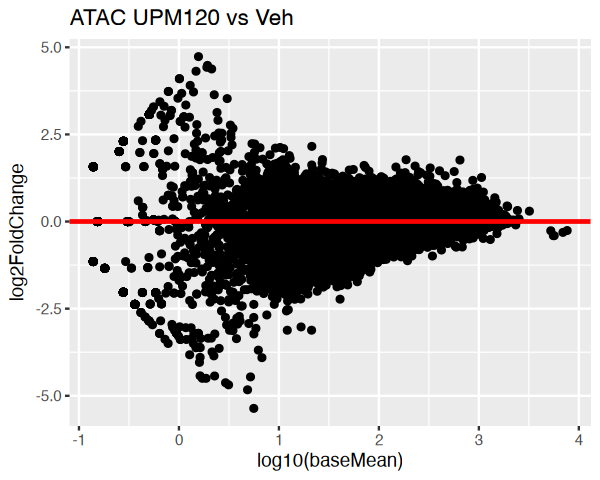

Warning message:
"Removed 1582 rows containing non-finite outside the scale range (`stat_bin()`)."


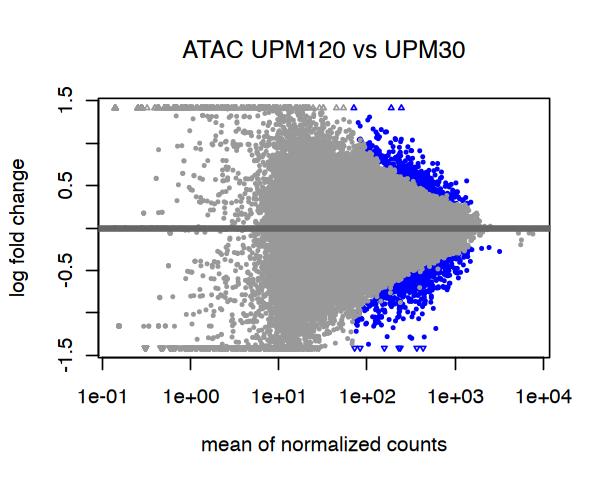

[1] 498

[1] 614

Warning message:
"Removed 1582 rows containing missing values or values outside the scale range
(`geom_point()`)."


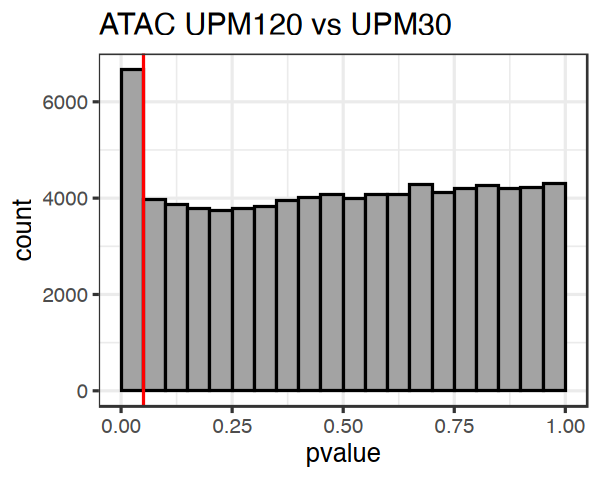

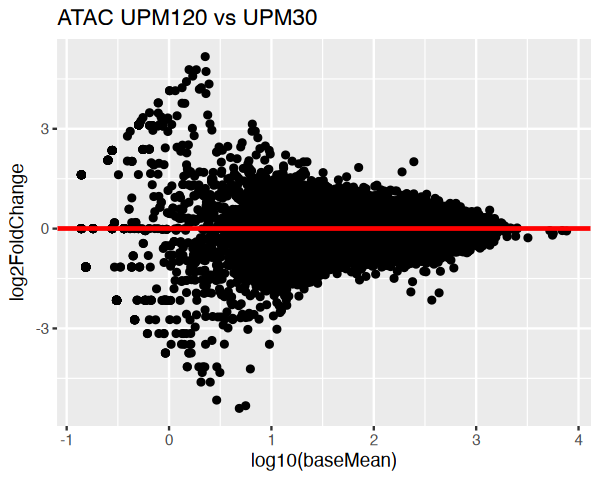

In [61]:
# UPM
# Gene Results
print("UPM30 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
res = results(dds_upm, contrast= c("Treatment", "UPM30", "Veh"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC UPM30 vs Veh")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC UPM30 vs Veh")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_UPM[["P30_vs_Veh"]] = up_sig_genes
All_Sig_UPM[["P30_vs_Veh_up"]] = up_sig_genes
Down_Sig_UPM[["P30_vs_Veh"]] = down_sig_genes
All_Sig_UPM[["P30_vs_Veh_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC UPM30 vs Veh")
write.table(res, 
            paste0(results_dir, "res_ATAC_UPM30_vs_Veh_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)

print("UPM120 vs Veh")
res = results(dds_upm, contrast= c("Treatment", "UPM120", "Veh"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC UPM120 vs Veh")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC UPM120 vs Veh")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_UPM[["P120_vs_Veh"]] = up_sig_genes
All_Sig_UPM[["P120_vs_Veh_up"]] = up_sig_genes
Down_Sig_UPM[["P120_vs_Veh"]] = down_sig_genes
All_Sig_UPM[["P120_vs_Veh_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC UPM120 vs Veh")
write.table(res, 
            paste0(results_dir, "res_ATAC_UPM120_vs_Veh_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)


print("UPM120 vs UPM30")
res = results(dds_upm, contrast= c("Treatment", "UPM120", "UPM30"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC UPM120 vs UPM30")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC UPM120 vs UPM30")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_UPM[["P120_vs_P30"]] = up_sig_genes
All_Sig_UPM[["P120_vs_P30_up"]] = up_sig_genes
Down_Sig_UPM[["P120_vs_P30"]] = down_sig_genes
All_Sig_UPM[["P120_vs_P30_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC UPM120 vs UPM30")
write.table(res, 
            paste0(results_dir, "res_ATAC_UPM120_vs_UPM30_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)



[1] "WSP30 vs Veh (NEC)"

out of 83623 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3355, 4%
LFC < 0 (down)     : 775, 0.93%
outliers [1]       : 0, 0%
low counts [2]     : 22678, 27%
(mean count < 47)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
"Removed 1398 rows containing non-finite outside the scale range (`stat_bin()`)."


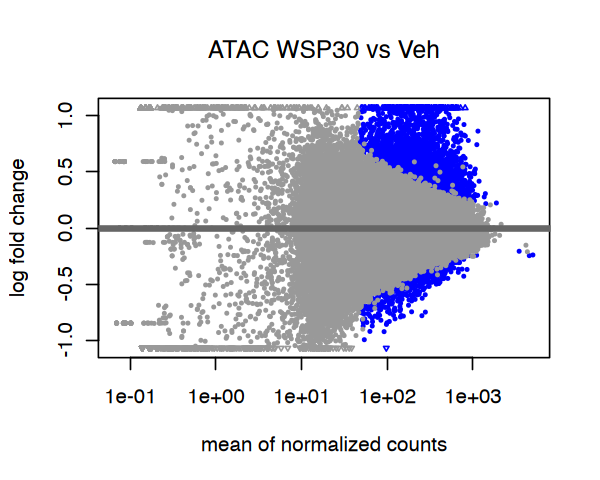

[1] 3355

[1] 775

Warning message:
"Removed 1398 rows containing missing values or values outside the scale range
(`geom_point()`)."


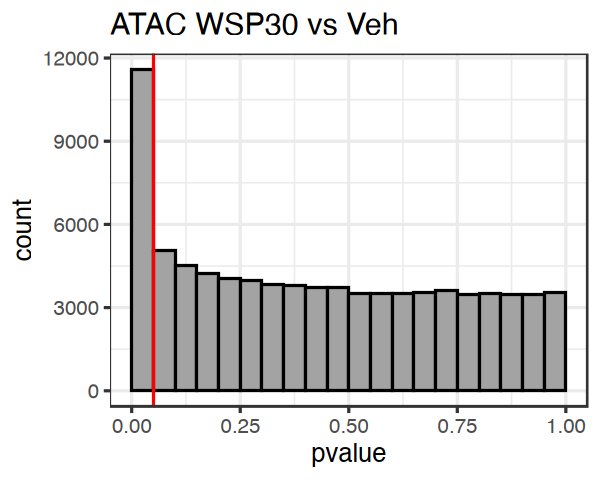

[1] "WSP120 vs Veh (NEC)"

out of 83623 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3045, 3.6%
LFC < 0 (down)     : 2302, 2.8%
outliers [1]       : 0, 0%
low counts [2]     : 24298, 29%
(mean count < 52)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



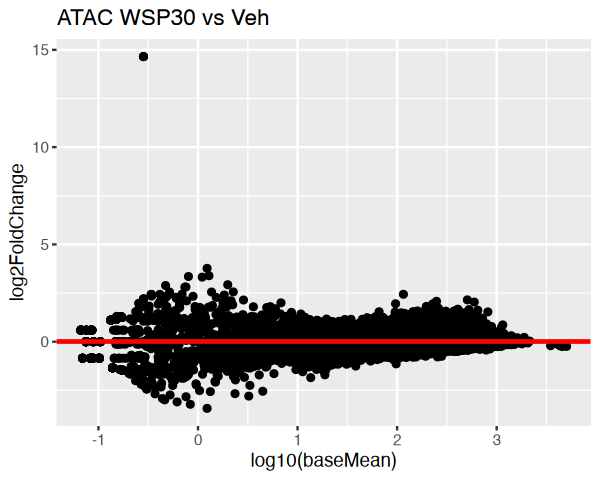

Warning message:
"Removed 1398 rows containing non-finite outside the scale range (`stat_bin()`)."


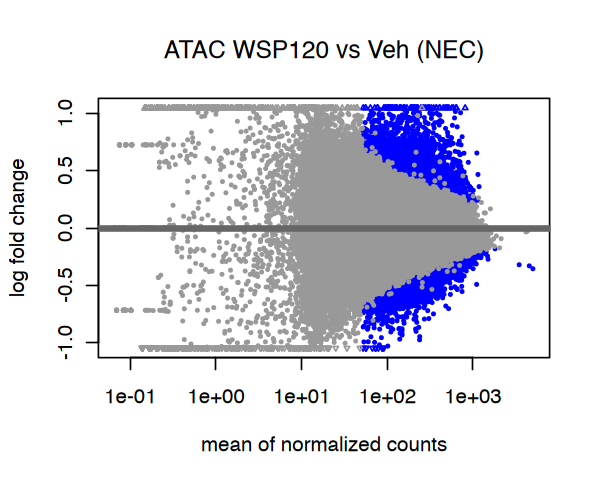

[1] 3045

[1] 2302

Warning message:
"Removed 1398 rows containing missing values or values outside the scale range
(`geom_point()`)."


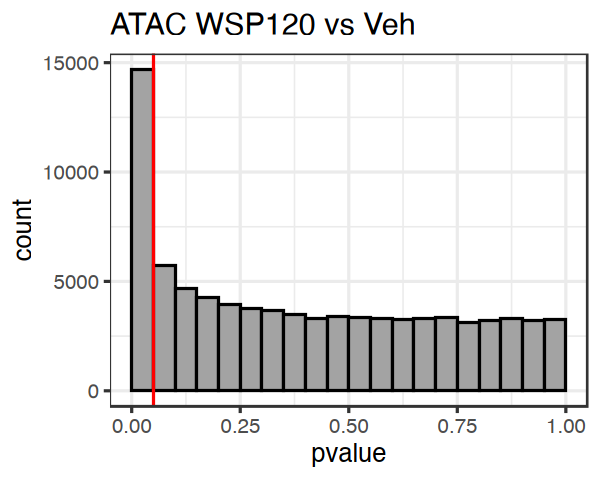

[1] "WSP120 vs WSP30 (NEC)"

out of 83623 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1644, 2%
LFC < 0 (down)     : 2722, 3.3%
outliers [1]       : 0, 0%
low counts [2]     : 21058, 25%
(mean count < 43)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



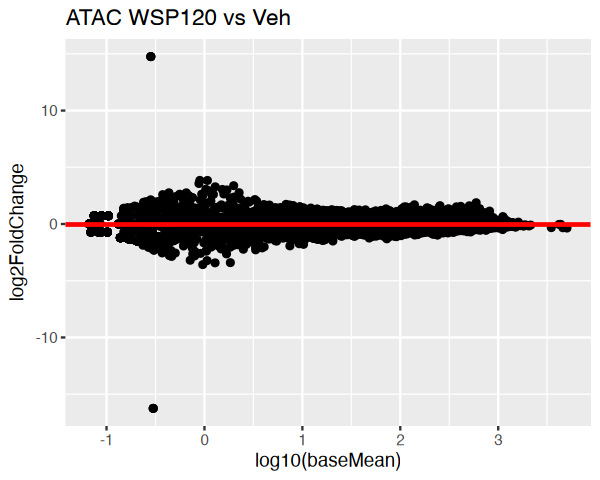

Warning message:
"Removed 1398 rows containing non-finite outside the scale range (`stat_bin()`)."


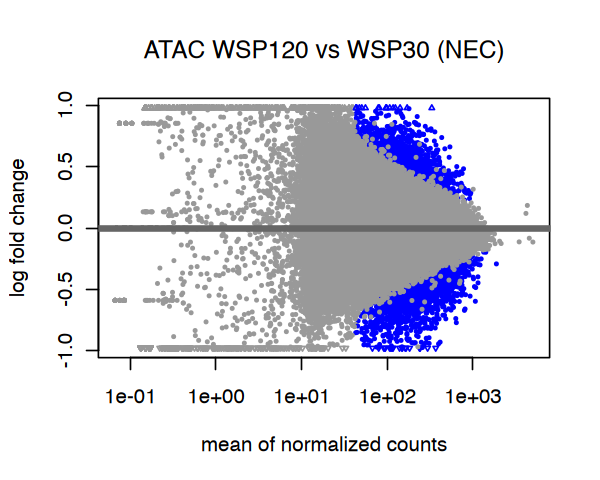

[1] 1644

[1] 2722

Warning message:
"Removed 1398 rows containing missing values or values outside the scale range
(`geom_point()`)."


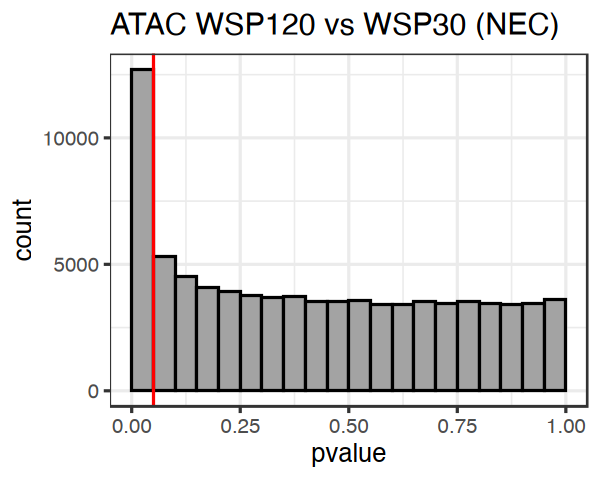

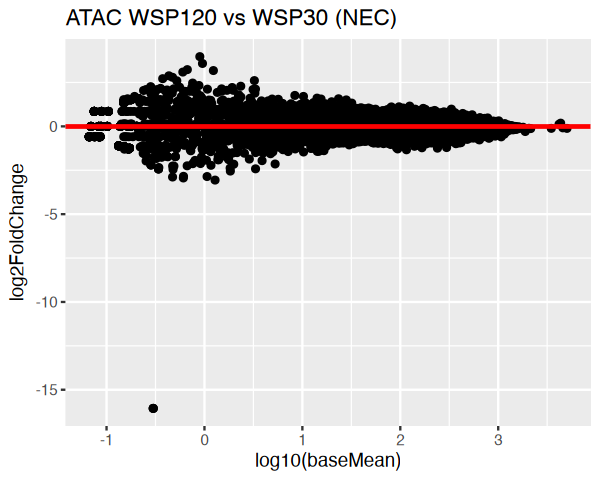

In [62]:
# WSP N#C
# Gene Results
print("WSP30 vs Veh (NEC)")
options(repr.plot.height=4, repr.plot.width=5)
res = results(dds_wsp_nec, contrast= c("Treatment", "WSP30", "Veh"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC WSP30 vs Veh")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC WSP30 vs Veh")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_WSP_NEC[["P30_vs_Veh"]] = up_sig_genes
All_Sig_WSP_NEC[["P30_vs_Veh_up"]] = up_sig_genes
Down_Sig_WSP_NEC[["P30_vs_Veh"]] = down_sig_genes
All_Sig_WSP_NEC[["P30_vs_Veh_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC WSP30 vs Veh")
write.table(res, 
            paste0(results_dir, "res_ATAC_WSP30_vs_Veh_NEC_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)

print("WSP120 vs Veh (NEC)")
res = results(dds_wsp_nec, contrast= c("Treatment", "WSP120", "Veh"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC WSP120 vs Veh (NEC)")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC WSP120 vs Veh")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_WSP_NEC[["P120_vs_Veh"]] = up_sig_genes
All_Sig_WSP_NEC[["P120_vs_Veh_up"]] = up_sig_genes
Down_Sig_WSP_NEC[["P120_vs_Veh"]] = down_sig_genes
All_Sig_WSP_NEC[["P120_vs_Veh_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC WSP120 vs Veh")
write.table(res, 
            paste0(results_dir, "res_ATAC_WSP120_vs_Veh_NEC_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)


print("WSP120 vs WSP30 (NEC)")
res = results(dds_wsp_nec, contrast= c("Treatment", "WSP120", "WSP30"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC WSP120 vs WSP30 (NEC)")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC WSP120 vs WSP30 (NEC)")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_WSP_NEC[["P120_vs_P30"]] = up_sig_genes
All_Sig_WSP_NEC[["P120_vs_P30_up"]] = up_sig_genes
Down_Sig_WSP_NEC[["P120_vs_P30"]] = down_sig_genes
All_Sig_WSP_NEC[["P120_vs_P30_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC WSP120 vs WSP30 (NEC)")
write.table(res, 
            paste0(results_dir, "res_ATAC_WSP120_vs_WSP30_NEC_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)



[1] "WSP30 vs Veh (B2B)"



out of 84997 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 357, 0.42%
LFC < 0 (down)     : 778, 0.92%
outliers [1]       : 0, 0%
low counts [2]     : 37901, 45%
(mean count < 96)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
"Removed 24 rows containing non-finite outside the scale range (`stat_bin()`)."


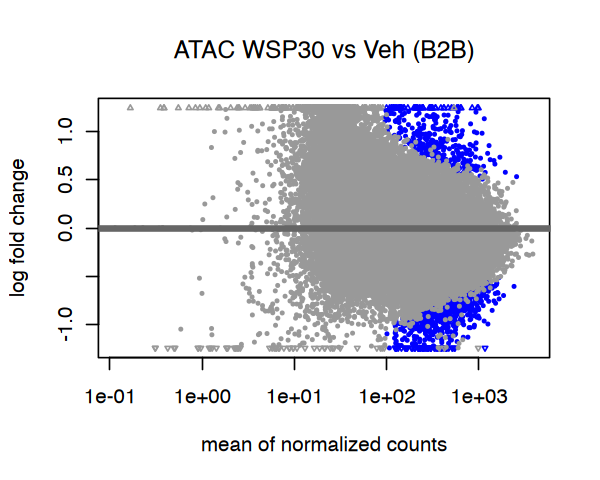

[1] 357

[1] 778

Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`)."


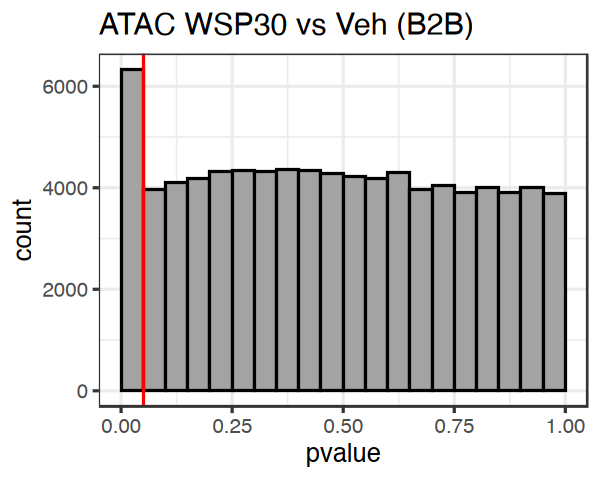

[1] "WSP120 vs Veh (B2B)"

out of 84997 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 0, 0%
LFC < 0 (down)     : 0, 0%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



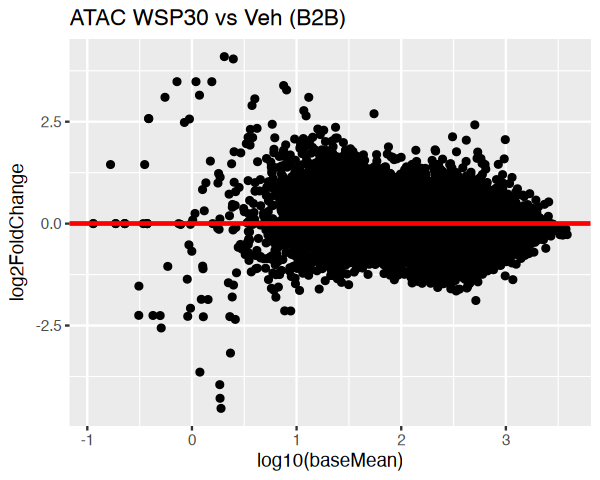

Warning message:
"Removed 24 rows containing non-finite outside the scale range (`stat_bin()`)."


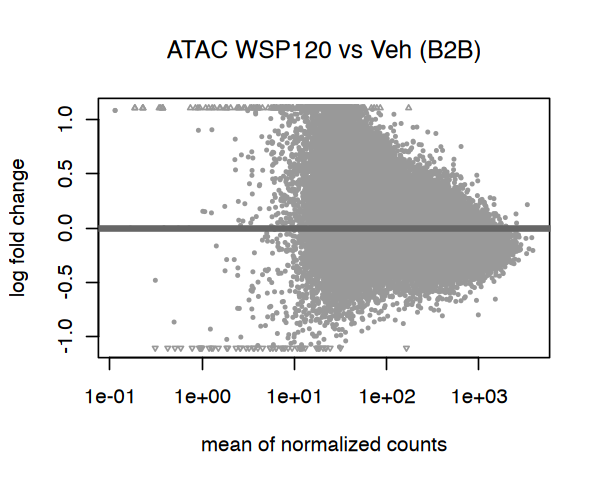

[1] 0

[1] 0

Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`)."


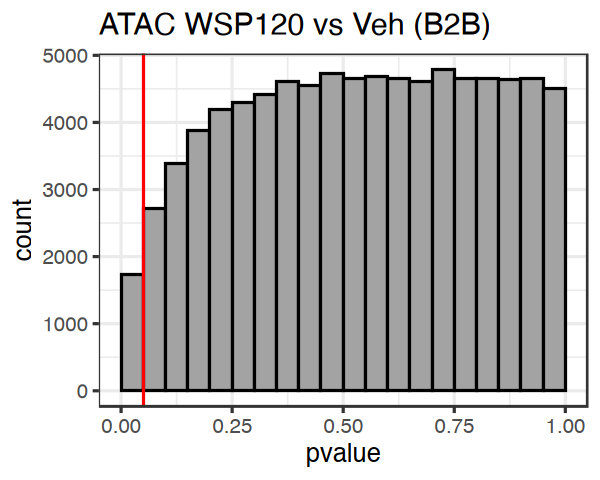

[1] "WSP120 vs WSP30 (B2B)"

out of 84997 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 309, 0.36%
LFC < 0 (down)     : 224, 0.26%
outliers [1]       : 0, 0%
low counts [2]     : 36253, 43%
(mean count < 88)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



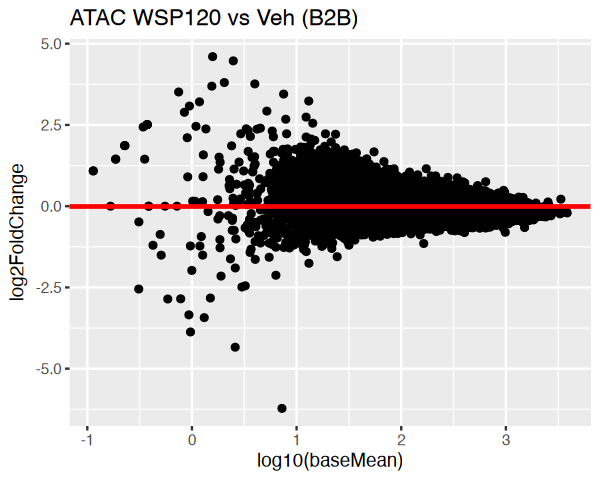

Warning message:
"Removed 24 rows containing non-finite outside the scale range (`stat_bin()`)."


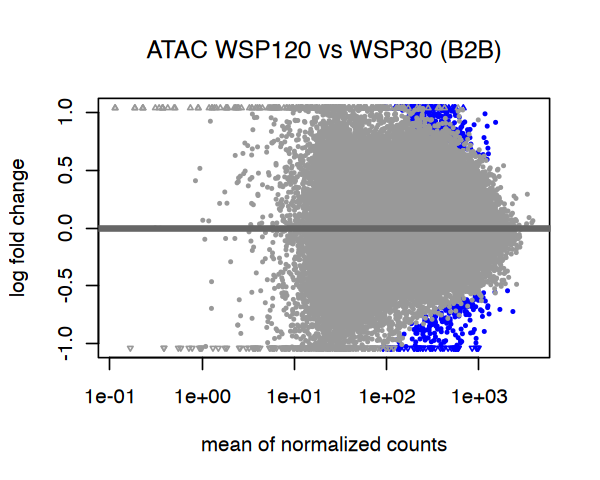

[1] 309

[1] 224

Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`)."


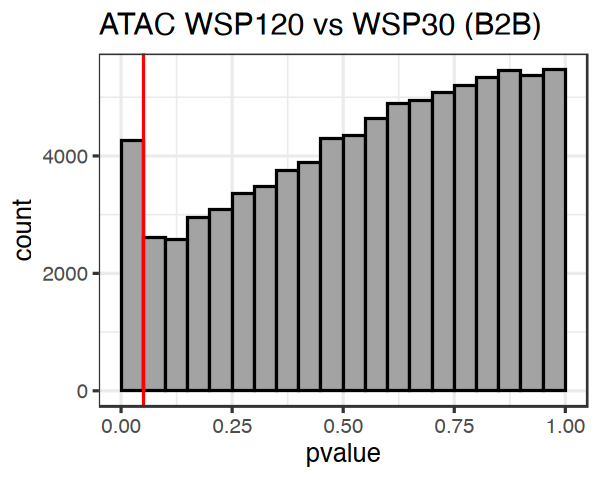

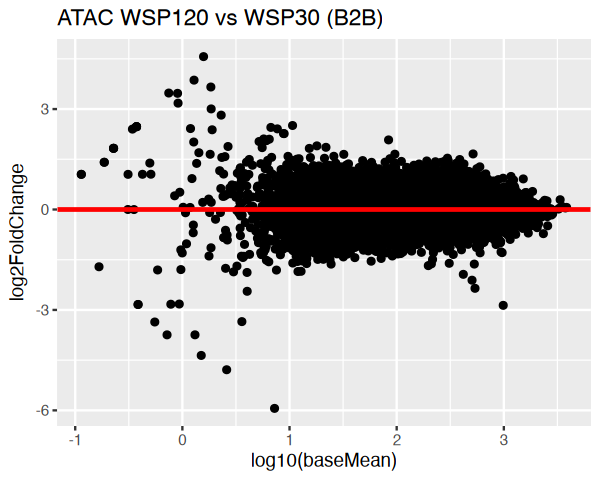

In [63]:
# WSP B2B
# Gene Results
print("WSP30 vs Veh (B2B)")
options(repr.plot.height=4, repr.plot.width=5)
res = results(dds_wsp_b2b, contrast= c("Treatment", "WSP30", "Veh"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC WSP30 vs Veh (B2B)")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC WSP30 vs Veh (B2B)")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_WSP_B2B[["P30_vs_Veh"]] = up_sig_genes
All_Sig_WSP_B2B[["P30_vs_Veh_up"]] = up_sig_genes
Down_Sig_WSP_B2B[["P30_vs_Veh"]] = down_sig_genes
All_Sig_WSP_B2B[["P30_vs_Veh_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC WSP30 vs Veh (B2B)")
write.table(res, 
            paste0(results_dir, "res_ATAC_WSP30_vs_Veh_B2B_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)

print("WSP120 vs Veh (B2B)")
res = results(dds_wsp_b2b, contrast= c("Treatment", "WSP120", "Veh"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC WSP120 vs Veh (B2B)")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC WSP120 vs Veh (B2B)")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_WSP_B2B[["P120_vs_Veh"]] = up_sig_genes
All_Sig_WSP_B2B[["P120_vs_Veh_up"]] = up_sig_genes
Down_Sig_WSP_B2B[["P120_vs_Veh"]] = down_sig_genes
All_Sig_WSP_B2B[["P120_vs_Veh_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC WSP120 vs Veh (B2B)")
write.table(res, 
            paste0(results_dir, "res_ATAC_WSP120_vs_Veh_B2B_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)


print("WSP120 vs WSP30 (B2B)")
res = results(dds_wsp_b2b, contrast= c("Treatment", "WSP120", "WSP30"), alpha=padj_threshold)
res <- res[order(res$pvalue),]
summary(res)
plotMA(res, main="ATAC WSP120 vs WSP30 (B2B)")
ggplot(data.frame(res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("ATAC WSP120 vs WSP30 (B2B)")
up_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange > 0), ])
down_sig_genes <- rownames(res[which(res$padj < padj_threshold & res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_WSP_B2B[["P120_vs_P30"]] = up_sig_genes
All_Sig_WSP_B2B[["P120_vs_P30_up"]] = up_sig_genes
Down_Sig_WSP_B2B[["P120_vs_P30"]] = down_sig_genes
All_Sig_WSP_B2B[["P120_vs_P30_down"]] = down_sig_genes
testing = as.data.frame(res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ATAC WSP120 vs WSP30 (B2B)")
write.table(res, 
            paste0(results_dir, "res_ATAC_WSP120_vs_WSP30_B2B_par_rat_Wd.txt"), 
            sep=",", quote=FALSE)



In [64]:
# Save Results
saveRDS(All_Sig_UPM, paste0(results_dir, "UPM_signontss_NEC_ATAC_DESeq2.rds"))
saveRDS(All_Sig_WSP_NEC, paste0(results_dir, "WSP_NEC_signontss_ATAC_DESeq2.rds"))

#save normalized counts
count_df = as.data.frame(counts(dds_upm, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/UPM_NEC_ATAC_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)


count_df = as.data.frame(counts(dds_wsp_nec, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/WSP_NEC_ATAC_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)

count_df = as.data.frame(counts(dds_wsp_b2b, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/WSP_B2B_ATAC_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)

gc()

,UPM120_1,UPM120_2,UPM30_1,UPM30_2,Veh_1,Veh_2,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr1:629266,343.3153,535.7073,620.1264,546.474,655.5304,765.7776,chr1:629266
chr1:629925,3819.9043,6108.2771,5654.7428,5287.205,6028.2112,7118.2505,chr1:629925


,D0_WSP120_1,D0_WSP120_2,D0_WSP30_1,D0_WSP30_2,D0_Veh_1,D0_Veh_2,D21_WSP120_1,D21_WSP120_2,D21_WSP30_1,D21_WSP30_2,D21_Veh_1,D21_Veh_2,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr1:629266,290.115,291.3432,311.0095,261.6749,398.4335,449.322,451.6729,528.5208,475.1771,289.9057,412.5664,343.6513,chr1:629266
chr1:629925,3178.690,3480.1105,3338.7545,3515.5014,3870.3784,4697.125,5021.4874,5582.0311,4962.6178,3881.1123,4525.2441,4113.2737,chr1:629925


,WSP120_1,WSP120_2,WSP30_1,WSP30_2,Veh_1,Veh_2,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr1:629266,355.071,311.8869,271.0864,239.7164,331.3563,242.596,chr1:629266
chr1:629925,2992.901,2520.4020,2586.8244,2026.5881,2459.1103,2577.434,chr1:629925


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,9337983,498.8,13605644,726.7,NA,13605644,726.7
Vcells,39168993,298.9,92707892,707.4,16384,92707892,707.4
